*Note: run train_test_val_split.ipynb before running this notebook*

In [69]:
import pandas as pd
import numpy as np
import igraph as ig
from tqdm import tqdm
from collections import defaultdict

## Data Preparation
- According to the PaySim data documentation, the type of fraud simulated involves the transfer of stolen funds. Fraudulent users first TRANSFER money from a victim account to a mule account, which then CASH_OUTS the funds
- The dataset is filtered to include only these relevant transaction types.
- We prepare the DataFrame for graph construction by creating sender (u) and receiver (v) identifiers and encoding transaction types as binary flags (is_transfer, is_cashout).
- The logarithm of the transaction amount is added as an additional feature to account for nonlinear effects in transaction size distributions.

In [70]:
TX_KEEP = {"TRANSFER", "CASH_OUT"}

def prep_df(df: pd.DataFrame) -> pd.DataFrame:
    # filter only relevant transaction types
    df = df.loc[df["type"].isin(TX_KEEP)].copy()

    df = df.sort_values("step").reset_index(drop=True)

    # rename instead of creating new columns to save memory
    df = df.rename(columns={"nameOrig": "u", "nameDest": "v"})
    # df["u"] = df["nameOrig"]
    # df["v"] = df["nameDest"]

    df["pair_key"] = df["u"] + "→" + df["v"]
    df["is_transfer"] = (df["type"] == "TRANSFER").astype(int)
    df["is_cashout"]  = (df["type"] == "CASH_OUT").astype(int)
    df["log_amount"]  = np.log1p(df["amount"])
    return df

## Graph helper functions
In order to assign centrality scores for each time window, we construct helper functions to
1. Aggregate multiple transactions (grouped by the u-v pair) into one edge, with the number of transactions and the total transacted value as edge features
2. Compute node centralities for BOTH u and v, for now we only include degree centrality, any additional measures can be added in (betweenness left out due to computational cost)
3. Split data into "blocks" of time, in which the network graph is built solely with data prior to it. This is to prevent data leakage, ensuring that information from future transactions does not influence feature computation for past events. block_size defines the number of hours within one block of time, window_size defines the number of hours prior to the block of time which is considered within the network.


In [71]:
def build_edgelist(edgelist: pd.DataFrame) -> pd.DataFrame:
    if edgelist.empty:
        return pd.DataFrame(columns=["u","v","w_amount","w_count"])
    agg = (edgelist
           .groupby(["u","v"])
           .agg(w_amount=("amount","sum"),
                w_count =("amount","size"))
           .reset_index())
    return agg

In [72]:
def compute_centralities(agg: pd.DataFrame) -> dict:
    if agg.empty:
        return {
            "pr": defaultdict(float), # PageRank weighted by amount
            "outdeg_amt": defaultdict(float),
            "indeg_amt": defaultdict(float),
            "outdeg_cnt": defaultdict(float),
            "indeg_cnt": defaultdict(float),
        }

    # --- build igraph ---
    nodes = pd.Index(pd.concat([agg["u"], agg["v"]]).unique())
    node_to_idx = {n: i for i, n in enumerate(nodes)}

    g = ig.Graph(directed=True)
    g.add_vertices(len(nodes))
    g.vs["name"] = list(nodes)
    edges_idx = list(zip(agg["u"].map(node_to_idx),
                         agg["v"].map(node_to_idx)))
    g.add_edges(edges_idx)

    g.es["w_amount"] = agg["w_amount"].astype(float).tolist()
    g.es["w_count"]  = agg["w_count"].astype(float).tolist()

    # --- centralities ---
    pr = g.pagerank(weights="w_amount")
    outdeg_amt = g.strength(mode="OUT", weights="w_amount")
    indeg_amt  = g.strength(mode="IN",  weights="w_amount")
    outdeg_cnt = g.strength(mode="OUT", weights="w_count")
    indeg_cnt  = g.strength(mode="IN",  weights="w_count")

    names = g.vs["name"]
    return {
        "pr": dict(zip(names, pr)),
        "outdeg_amt": dict(zip(names, outdeg_amt)),
        "indeg_amt":  dict(zip(names, indeg_amt)),
        "outdeg_cnt": dict(zip(names, outdeg_cnt)),
        "indeg_cnt":  dict(zip(names, indeg_cnt)),
    }

In [73]:
def rolling_features(
        df: pd.DataFrame,
        block_size: int = 10,
        window_size: int = 50
    ) -> pd.DataFrame:
    # e.g. For each block of 10 time steps, use the previous 50 time steps of transactions to compute graph features.

    df = df.copy()
    df["block"] = (df["step"] // block_size).astype(int)

    # placeholder columns
    for col in [
        "sender_pr","receiver_pr",
        "sender_outdeg_amt","sender_indeg_amt",
        "receiver_outdeg_amt","receiver_indeg_amt",
        "sender_outdeg_cnt","sender_indeg_cnt",
        "receiver_outdeg_cnt","receiver_indeg_cnt",
        "pagerank_diff","outdeg_amt_diff","indeg_amt_diff",
        "outdeg_cnt_diff","indeg_cnt_diff"
    ]:
        df[col] = 0.0

    for b in tqdm(sorted(df["block"].unique()), desc="Computing rolling features", leave=False):
        block_mask = df["block"] == b
        block_min_step = int(df.loc[block_mask, "step"].min())
        hist_mask = (df["step"] < block_min_step) & (df["step"] >= block_min_step - window_size)
        hist_edges = df.loc[hist_mask, ["u","v","amount","step"]]
        agg = build_edgelist(hist_edges)
        cent = compute_centralities(agg)

        idx = df.index[block_mask]
        df.loc[idx, "sender_pr"] = df.loc[idx, "u"].map(cent["pr"]).fillna(0.0)
        df.loc[idx, "receiver_pr"] = df.loc[idx, "v"].map(cent["pr"]).fillna(0.0)

        df.loc[idx, "sender_outdeg_amt"] = df.loc[idx, "u"].map(cent["outdeg_amt"]).fillna(0.0)
        df.loc[idx, "sender_indeg_amt"]  = df.loc[idx, "u"].map(cent["indeg_amt"]).fillna(0.0)
        df.loc[idx, "receiver_outdeg_amt"] = df.loc[idx, "v"].map(cent["outdeg_amt"]).fillna(0.0)
        df.loc[idx, "receiver_indeg_amt"]  = df.loc[idx, "v"].map(cent["indeg_amt"]).fillna(0.0)

        df.loc[idx, "sender_outdeg_cnt"] = df.loc[idx, "u"].map(cent["outdeg_cnt"]).fillna(0.0)
        df.loc[idx, "sender_indeg_cnt"]  = df.loc[idx, "u"].map(cent["indeg_cnt"]).fillna(0.0)
        df.loc[idx, "receiver_outdeg_cnt"] = df.loc[idx, "v"].map(cent["outdeg_cnt"]).fillna(0.0)
        df.loc[idx, "receiver_indeg_cnt"]  = df.loc[idx, "v"].map(cent["indeg_cnt"]).fillna(0.0)

        df.loc[idx, "pagerank_diff"]  = df.loc[idx, "sender_pr"] - df.loc[idx, "receiver_pr"]
        df.loc[idx, "outdeg_amt_diff"] = df.loc[idx, "sender_outdeg_amt"] - df.loc[idx, "receiver_outdeg_amt"]
        df.loc[idx, "indeg_amt_diff"]  = df.loc[idx, "sender_indeg_amt"]  - df.loc[idx, "receiver_indeg_amt"]
        df.loc[idx, "outdeg_cnt_diff"] = df.loc[idx, "sender_outdeg_cnt"] - df.loc[idx, "receiver_outdeg_cnt"]
        df.loc[idx, "indeg_cnt_diff"]  = df.loc[idx, "sender_indeg_cnt"]  - df.loc[idx, "receiver_indeg_cnt"]

    return df

## Main function


In [74]:
def build_feature_table(df_raw: pd.DataFrame,
                        block_size=10,
                        window_size=50) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame]:
    df = prep_df(df_raw)
    df = rolling_features(df, block_size=block_size, window_size=window_size)

    # features to be used in Random Forest Classifier
    feature_cols = [
        "amount","log_amount","is_transfer","is_cashout",
        "sender_pr","receiver_pr",
        "sender_outdeg_amt","sender_indeg_amt","receiver_outdeg_amt","receiver_indeg_amt",
        "sender_outdeg_cnt","sender_indeg_cnt","receiver_outdeg_cnt","receiver_indeg_cnt",
        "pagerank_diff","outdeg_amt_diff","indeg_amt_diff","outdeg_cnt_diff","indeg_cnt_diff",
    ]
    
    X = df[feature_cols].fillna(0).copy()
    y = df["isFraud"].astype(int)
    meta = df[["step","type","u","v","pair_key"]].copy()
    return X, y, meta

## Preparation of train/val/test data

Full dataset consists 31 days of data, with about 3 days of data in val and test. We arbitrarily set block_size to 12 and window_size to 48.



In [75]:
df_train = pd.read_csv('../data/splits/train.csv')
df_val = pd.read_csv('../data/splits/val.csv')
df_test = pd.read_csv('../data/splits/test.csv')

print("Building feature tables for training data ...")
Xtrain, ytrain, metatrain = build_feature_table(df_train, block_size=6, window_size=48)

print("Building feature tables for validation data ...")
Xval, yval, metaval = build_feature_table(df_val, block_size=6, window_size=48)

print("Building feature tables for test data ...")
Xtest, ytest, metatest = build_feature_table(df_test, block_size=6, window_size=48)

## XGBoost Classifier
- Use RandomSearchCV to tune the hyperparameters
- Evaluate with validation set to pick which early stopping value to prevent overfitting
- Evaluate with test Set

In [84]:
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import ParameterSampler
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    confusion_matrix
)

param_grid = {
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.005, 0.01, 0.05],
    'n_estimators': [50, 100, 300, 600],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5, 10],
    'gamma': [0, 0.1, 0.5, 1],
    'reg_alpha': [0, 0.05, 0.1, 0.5, 1],
    'reg_lambda': [0.5, 1, 2],
}

n_iter = 30
param_list = list(ParameterSampler(param_grid, n_iter=n_iter, random_state=42))
results = []

for params in tqdm(param_list, desc="Random Search Hyperparameter Tuning"):
    model = XGBClassifier(
        **params,
        scale_pos_weight=(len(ytrain) - sum(ytrain)) / sum(ytrain),
        random_state=42,
        eval_metric="auc",
        n_jobs=-1
    )

    model.fit(Xtrain, ytrain)

    yval_pred = model.predict_proba(Xval)[:, 1]
    auc = roc_auc_score(yval, yval_pred)
    pr_auc = average_precision_score(yval, yval_pred)

    results.append({
        **params,
        "auc": auc,
        "pr_auc": pr_auc,
    })

df_results = pd.DataFrame(results).sort_values("auc", ascending=False)
print(df_results.head(5))

Random Search Hyperparameter Tuning: 100%|██████████| 30/30 [06:16<00:00, 12.56s/it]

    subsample  reg_lambda  reg_alpha  n_estimators  min_child_weight  \
24        1.0         0.5        0.1            50                 5   
2         0.8         2.0        0.1           100                 3   
10        0.8         1.0        0.5            50                 1   
28        1.0         1.0        0.5           600                 5   
6         1.0         2.0        0.5            50                 5   

    max_depth  learning_rate  gamma  colsample_bytree       auc    pr_auc  
24          7          0.005    0.5               0.8  0.828552  0.156954  
2           7          0.010    0.1               1.0  0.825317  0.163996  
10          9          0.005    1.0               1.0  0.825174  0.157279  
28          5          0.010    0.1               0.8  0.824772  0.157878  
6           5          0.010    0.5               1.0  0.824150  0.156888  


In [91]:
# # Best model from Randomized Search
best_model_info = df_results.iloc[0]
best_model_info = best_model_info.to_dict()
best_model_info = {k: int(v) if isinstance(v, float) and v.is_integer() else v
               for k, v in best_model_info.items()}

print("=== Best model hyperparameters from Random Search Hyperparameter Tuning ===")
for k, v in best_model_info.items():
    print(f"{k:<20}: {v}")

# remove metrics from best_model_info to get only parameters
best_model_info.pop("auc", None)
best_model_info.pop("pr_auc", None)
best_params = best_model_info

=== Best model hyperparameters from Random Search Hyperparameter Tuning ===
subsample           : 1
reg_lambda          : 0.5
reg_alpha           : 0.1
n_estimators        : 50
min_child_weight    : 5
max_depth           : 7
learning_rate       : 0.005
gamma               : 0.5
colsample_bytree    : 0.8
auc                 : 0.828551512944472
pr_auc              : 0.1569538749835958


In [86]:
early_stopping_values = [10, 50, 100, 200]
results = []

for esr in tqdm(early_stopping_values, "Training with different early stopping values"):    
    model = XGBClassifier(
        **best_params,  
        scale_pos_weight=(len(ytrain) - sum(ytrain)) / sum(ytrain),
        random_state=42,
        eval_metric="auc",
        early_stopping_rounds=esr,
        n_jobs=-1
    )
    
    model.fit(
        Xtrain, ytrain,
        eval_set=[(Xval, yval)],
        verbose=False
    )
    
    # Predict on validation set
    yval_pred = model.predict_proba(Xval)[:, 1]
    
    # Compute metrics
    val_auc = roc_auc_score(yval, yval_pred)
    val_pr  = average_precision_score(yval, yval_pred)
    
    results.append({
        "early_stopping_rounds": esr,
        "best_iteration": model.best_iteration,
        "validation_auc": val_auc,
        "validation_pr_auc": val_pr,
    })

# Convert to DataFrame for easy viewing
df_esr = pd.DataFrame(results)
print(df_esr)

# update best_params with best n_estimators from early stopping
best_row = df_esr.loc[df_esr["validation_auc"].idxmax()]
best_iter = int(best_row["best_iteration"])
best_params["n_estimators"] = best_iter

Training with different early stopping values: 100%|██████████| 4/4 [00:14<00:00,  3.71s/it]

   early_stopping_rounds  best_iteration  validation_auc  validation_pr_auc
0                     10               0         0.82894           0.138256
1                     50               0         0.82894           0.138256
2                    100               0         0.82894           0.138256
3                    200               0         0.82894           0.138256


In [92]:
Xtrain_full = pd.concat([Xtrain, Xval])
ytrain_full = pd.concat([ytrain, yval])

# Final model using tuned parameters
best_xgb = XGBClassifier(
    **best_params,          
    random_state=42,
    n_jobs=-1,
    eval_metric="auc"
)

best_xgb.fit(Xtrain_full, ytrain_full)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


Test ROC-AUC: 0.8454968592127156
Test PR-AUC : 0.24708798205672625


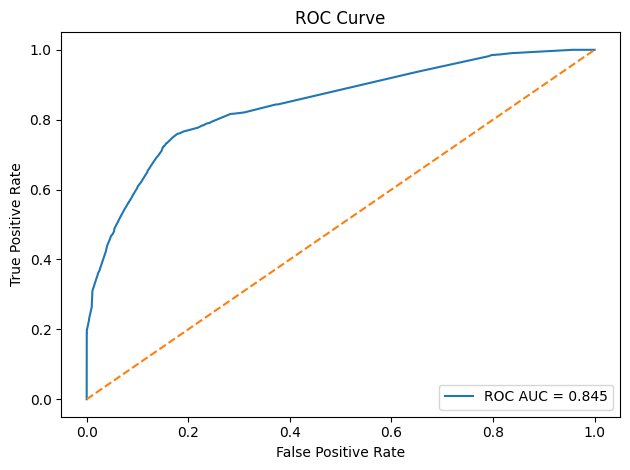

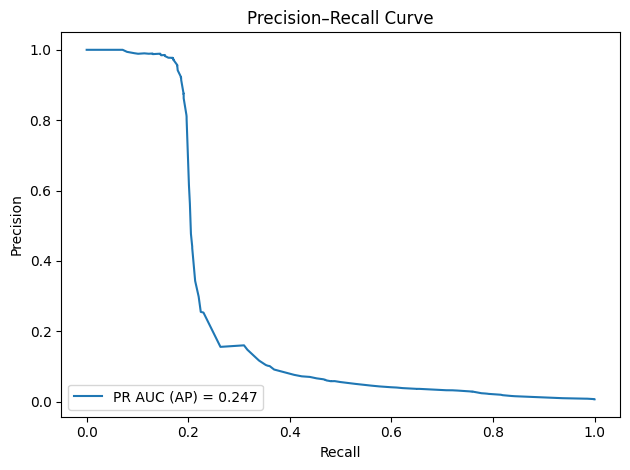

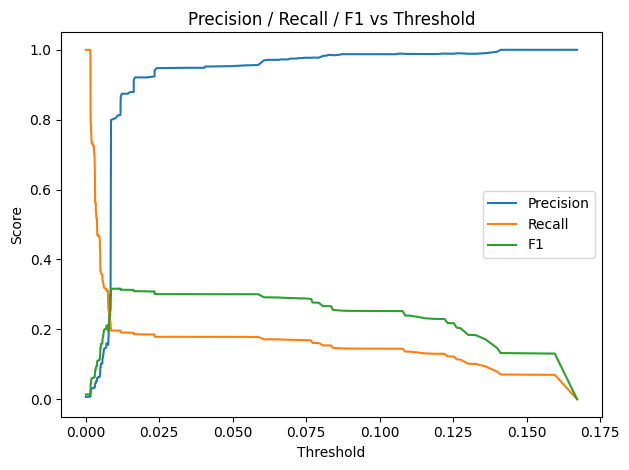

In [95]:
proba = best_xgb.predict_proba(Xtest)[:,1]
print("Test ROC-AUC:", roc_auc_score(ytest, proba))
print("Test PR-AUC :", average_precision_score(ytest, proba))

y_true = ytest.astype(int)
y_score = proba

fpr, tpr, thr_roc = roc_curve(y_true, y_score)
roc_auc = roc_auc_score(y_true, y_score)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

prec, rec, thr_pr = precision_recall_curve(y_true, y_score)
ap = average_precision_score(y_true, y_score)

plt.figure()
plt.plot(rec, prec, label=f"PR AUC (AP) = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

thr = np.r_[0.0, thr_pr]  # prepend 0 to align lengths
f1 = 2 * (prec * rec) / np.clip(prec + rec, 1e-12, None)

plt.figure()
plt.plot(thr, prec, label="Precision")
plt.plot(thr, rec,  label="Recall")
plt.plot(thr, f1,   label="F1")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 vs Threshold")
plt.legend()
plt.tight_layout()
plt.show()

In [96]:
from sklearn.metrics import classification_report

# Choose threshold based on business requirements/ PR curve
best_thr = thr[np.argmax(f1)]
print(f"Best F1 Threshold: {best_thr:.4f}")

y_pred = (proba >= best_thr).astype(int)

print("Classification Report:")
print(classification_report(ytest, y_pred, digits=2))

Best F1 Threshold: 0.0108
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    625350
           1       0.81      0.20      0.32      4336

    accuracy                           0.99    629686
   macro avg       0.90      0.60      0.66    629686
weighted avg       0.99      0.99      0.99    629686

